In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import os
import cv2
import numpy as np
from collections import defaultdict

data = []
labels = []

emotion_map = {
    'AN':0,
    'DI':1,
    'AF':2,
    'HA':3,
    'SA':4,
    'SU':5,
    'NE':6
}

emotion_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Sad',
    'Surprise',
    'Neutral'
]

kdef_path = "/kaggle/input/datasets/navneet0094/kdef-da/KDEF_and_AKDEF/KDEF"

emotion_counter = defaultdict(int)
MAX_PER_CLASS = 200

for folder in os.listdir(kdef_path):

    folder_path = os.path.join(kdef_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):

        if not img_name.endswith(".JPG"):
            continue

        emotion_code = img_name[4:6]

        if emotion_code not in emotion_map:
            continue

        label = emotion_map[emotion_code]

        if emotion_counter[label] >= MAX_PER_CLASS:
            continue

        img_path = os.path.join(folder_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (128,128))

        data.append(img)
        labels.append(label)

        emotion_counter[label] += 1

data = np.array(data)
labels = np.array(labels)

print("Data Shape:", data.shape)
print("Labels Shape:", labels.shape)

for i in range(7):
    print(emotion_names[i], np.sum(labels==i))

Data Shape: (1400, 128, 128)
Labels Shape: (1400,)
Angry 200
Disgust 200
Fear 200
Happy 200
Sad 200
Surprise 200
Neutral 200


In [3]:
from skimage.feature import hog

X_hog = []

for img in data:

    feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(feat)

X_hog = np.array(X_hog)

print(X_hog.shape)

(1400, 8100)


In [4]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

X_mobilenet = []

for img in data:

    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    img_rgb = cv2.resize(img_rgb,(224,224))

    img_rgb = preprocess_input(img_rgb)

    img_rgb = np.expand_dims(img_rgb,axis=0)

    feat = mobilenet.predict(img_rgb,verbose=0)

    X_mobilenet.append(feat.flatten())

X_mobilenet = np.array(X_mobilenet)

print(X_mobilenet.shape)

2026-06-29 06:59:21.113707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782716361.305640      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782716361.365605      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782716361.815604      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782716361.815636      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782716361.815639      58 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(1400, 1280)


In [5]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

X_vgg = []

for img in data:

    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    img_rgb = cv2.resize(img_rgb,(224,224))

    img_rgb = vgg_preprocess(img_rgb)

    img_rgb = np.expand_dims(img_rgb,axis=0)

    feat = vgg.predict(img_rgb,verbose=0)

    X_vgg.append(feat.flatten())

X_vgg = np.array(X_vgg)

print(X_vgg.shape)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(1400, 512)


In [6]:
from sklearn.preprocessing import StandardScaler

hog_scaler = StandardScaler()
mobile_scaler = StandardScaler()
vgg_scaler = StandardScaler()

X_hog_scaled = hog_scaler.fit_transform(X_hog)

X_mobile_scaled = mobile_scaler.fit_transform(X_mobilenet)

X_vgg_scaled = vgg_scaler.fit_transform(X_vgg)

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score

def evaluate_fusion(hog_w, mobile_w, vgg_w):

    X_fusion = np.concatenate([
        X_hog_scaled * hog_w,
        X_mobile_scaled * mobile_w,
        X_vgg_scaled * vgg_w
    ], axis=1)

    model = Pipeline([
        ('svm',SVC(
            kernel='linear',
            probability=True
        ))
    ])

    y_probs = cross_val_predict(
        model,
        X_fusion,
        labels,
        cv=10,
        method='predict_proba',
        n_jobs=-1
    )

    y_pred = np.argmax(y_probs,axis=1)

    confidence = np.max(y_probs,axis=1)

    overall_acc = accuracy_score(labels,y_pred)

    accepted = confidence >= 0.60

    filtered_acc = accuracy_score(
        labels[accepted],
        y_pred[accepted]
    )

    return overall_acc*100, filtered_acc*100

In [8]:
results = []

weights_list = [

    (0.34,0.33,0.33),
    (0.60,0.30,0.10),
    (0.70,0.20,0.10),
    (0.50,0.40,0.10),
    (0.35,0.35,0.30)

]

for h,m,v in weights_list:

    overall,filtered = evaluate_fusion(h,m,v)

    results.append([
        h,m,v,
        round(overall,2),
        round(filtered,2)
    ])

    print(
        h,m,v,
        overall,
        filtered
    )

0.34 0.33 0.33 58.5 87.11484593837535
0.6 0.3 0.1 56.00000000000001 85.26315789473684
0.7 0.2 0.1 55.00000000000001 87.24279835390946
0.5 0.4 0.1 56.57142857142857 85.8044164037855
0.35 0.35 0.3 58.214285714285715 86.8632707774799


In [9]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "W_HOG",
        "W_MobileNet",
        "W_VGG",
        "Accuracy",
        "Filtered Accuracy"
    ]
)

results_df

,W_HOG,W_MobileNet,W_VGG,Accuracy,Filtered Accuracy
0,0.34,0.33,0.33,58.50,87.11
1,0.60,0.30,0.10,56.00,85.26
2,0.70,0.20,0.10,55.00,87.24
3,0.50,0.40,0.10,56.57,85.80
4,0.35,0.35,0.30,58.21,86.86


In [10]:
winner = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("\nWINNER MODEL\n")
print(winner)


WINNER MODEL

W_HOG                 0.34
W_MobileNet           0.33
W_VGG                 0.33
Accuracy             58.50
Filtered Accuracy    87.11
Name: 0, dtype: float64


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

data = []
labels = []

emotion_map = {
    'AN':0,
    'DI':1,
    'AF':2,
    'HA':3,
    'SA':4,
    'SU':5,
    'NE':6
}

emotion_names = [
    'Angry',
    'Disgust',
    'Fear',
    'Happy',
    'Sad',
    'Surprise',
    'Neutral'
]

kdef_path = "/kaggle/input/datasets/navneet0094/kdef-da/KDEF_and_AKDEF/KDEF"

MAX_PER_CLASS = 200

counter = defaultdict(int)

for folder in os.listdir(kdef_path):

    folder_path = os.path.join(kdef_path, folder)

    if not os.path.isdir(folder_path):
        continue

    for img_name in os.listdir(folder_path):

        if not img_name.endswith(".JPG"):
            continue

        emotion_code = img_name[4:6]

        if emotion_code not in emotion_map:
            continue

        label = emotion_map[emotion_code]

        if counter[label] >= MAX_PER_CLASS:
            continue

        img_path = os.path.join(folder_path,img_name)

        img = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img,(128,128))

        data.append(img)
        labels.append(label)

        counter[label] += 1

data = np.array(data)
labels = np.array(labels)

print("Data Shape:",data.shape)
print("Labels:",np.unique(labels))

Data Shape: (1400, 128, 128)
Labels: [0 1 2 3 4 5 6]


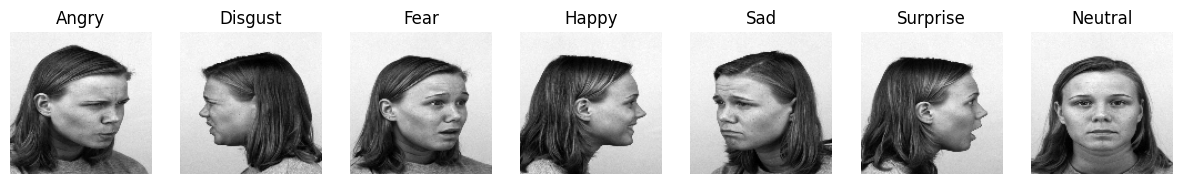

In [13]:
plt.figure(figsize=(15,5))

for i in range(7):

    idx = np.where(labels==i)[0][0]

    plt.subplot(1,7,i+1)

    plt.imshow(data[idx],cmap='gray')

    plt.title(emotion_names[i])

    plt.axis('off')

plt.show()

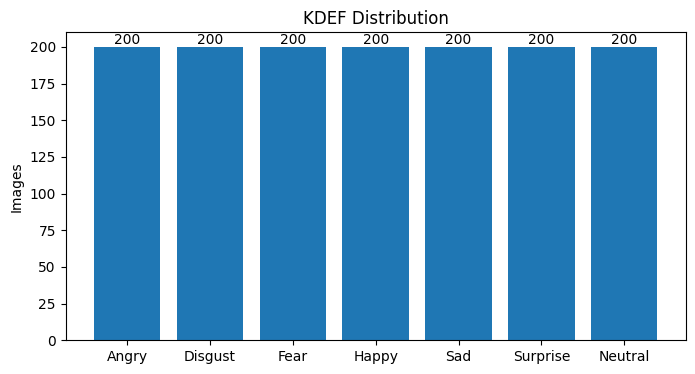

In [14]:
unique,counts = np.unique(labels,return_counts=True)

plt.figure(figsize=(8,4))

bars = plt.bar(emotion_names,counts)

plt.title("KDEF Distribution")

plt.ylabel("Images")

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+2,
        int(bar.get_height()),
        ha='center'
    )

plt.show()

In [15]:
from skimage.feature import hog

X_hog = []

for img in data:

    feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog.append(feat)

X_hog = np.array(X_hog)

print(X_hog.shape)

(1400, 8100)


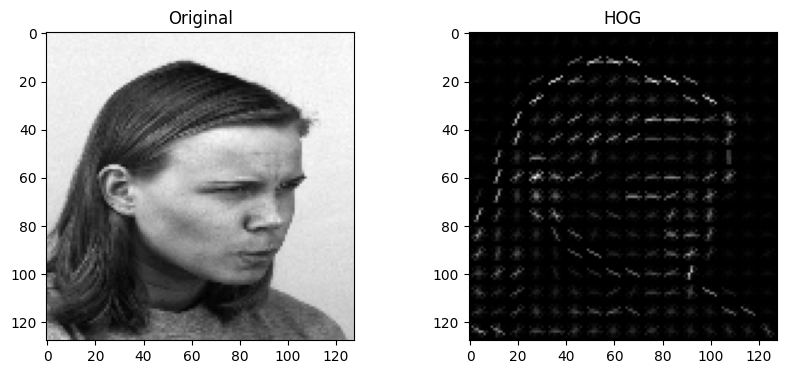

In [16]:
sample = data[0]

features,hog_img = hog(
    sample,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample,cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_img,cmap='gray')
plt.title("HOG")

plt.show()

In [17]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import VGG16

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

vgg = VGG16(
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

/tmp/ipykernel_58/3988259952.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


In [18]:
X_mobile = []

for img in data:

    x = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)

    x = cv2.resize(x,(224,224))

    x = preprocess_input(x)

    x = np.expand_dims(x,axis=0)

    feat = mobilenet.predict(x,verbose=0)

    X_mobile.append(feat.flatten())

X_mobile = np.array(X_mobile)

print(X_mobile.shape)

(1400, 1280)


In [19]:
X_vgg = []

for img in data:

    x = cv2.cvtColor(img,cv2.COLOR_GRAY2RGB)

    x = cv2.resize(x,(224,224))

    x = vgg_preprocess(x)

    x = np.expand_dims(x,axis=0)

    feat = vgg.predict(x,verbose=0)

    X_vgg.append(feat.flatten())

X_vgg = np.array(X_vgg)

print(X_vgg.shape)

(1400, 512)


In [20]:
from sklearn.preprocessing import StandardScaler

X_hog_scaled = StandardScaler().fit_transform(X_hog)

X_mobile_scaled = StandardScaler().fit_transform(X_mobile)

X_vgg_scaled = StandardScaler().fit_transform(X_vgg)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

def evaluate_weights(h,m,v):

    print("="*70)
    print(f"Weights : {h},{m},{v}")
    print("="*70)

    X_fusion = np.concatenate([
        X_hog_scaled*h,
        X_mobile_scaled*m,
        X_vgg_scaled*v
    ],axis=1)

    model = Pipeline([
        ('svm',
         SVC(
             kernel='linear',
             probability=True
         ))
    ])

    y_probs = cross_val_predict(
        model,
        X_fusion,
        labels,
        cv=10,
        method='predict_proba'
    )

    y_pred = np.argmax(y_probs,axis=1)

    confidence = np.max(y_probs,axis=1)

    overall_acc = accuracy_score(labels,y_pred)

    print(
        classification_report(
            labels,
            y_pred,
            target_names=emotion_names
        )
    )

    plt.figure(figsize=(8,4))
    plt.hist(confidence,bins=20)
    plt.title(f"Confidence Distribution {h,m,v}")
    plt.show()

    thresholds = [0.4,0.5,0.6,0.7,0.8]

    for t in thresholds:

        mask = confidence>=t

        acc = accuracy_score(
            labels[mask],
            y_pred[mask]
        )

        print(
            f"T={t} | "
            f"Accepted={np.sum(mask)} | "
            f"Rejected={np.sum(~mask)} | "
            f"Acc={acc:.4f}"
        )

    accepted = confidence>=0.6

    filtered_acc = accuracy_score(
        labels[accepted],
        y_pred[accepted]
    )

    plt.figure(figsize=(8,5))

    thresh = np.arange(
        0.1,
        1.0,
        0.05
    )

    accs = []

    for t in thresh:

        msk = confidence>=t

        if np.sum(msk)>0:

            accs.append(
                accuracy_score(
                    labels[msk],
                    y_pred[msk]
                )
            )
        else:
            accs.append(0)

    plt.plot(thresh,accs,marker='o')

    plt.title(
        f"Accuracy vs Threshold {h,m,v}"
    )

    plt.show()

    return overall_acc*100, filtered_acc*100

Weights : 0.34,0.33,0.33
              precision    recall  f1-score   support

       Angry       0.59      0.66      0.62       200
     Disgust       0.60      0.60      0.60       200
        Fear       0.40      0.40      0.40       200
       Happy       0.76      0.71      0.74       200
         Sad       0.43      0.39      0.41       200
    Surprise       0.72      0.72      0.72       200
     Neutral       0.54      0.56      0.55       200

    accuracy                           0.58      1400
   macro avg       0.58      0.58      0.58      1400
weighted avg       0.58      0.58      0.58      1400



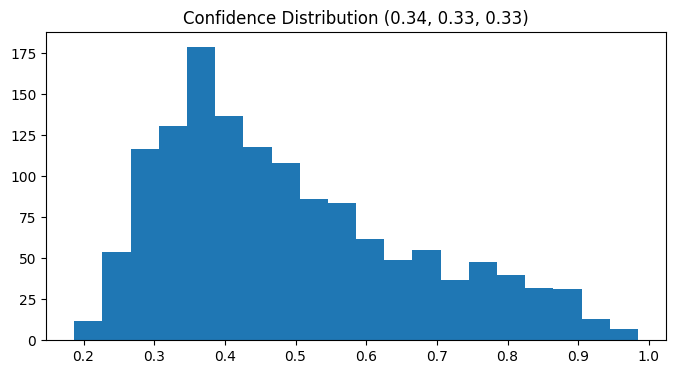

T=0.4 | Accepted=851 | Rejected=549 | Acc=0.7051
T=0.5 | Accepted=565 | Rejected=835 | Acc=0.7929
T=0.6 | Accepted=353 | Rejected=1047 | Acc=0.8612
T=0.7 | Accepted=216 | Rejected=1184 | Acc=0.8796
T=0.8 | Accepted=106 | Rejected=1294 | Acc=0.8962


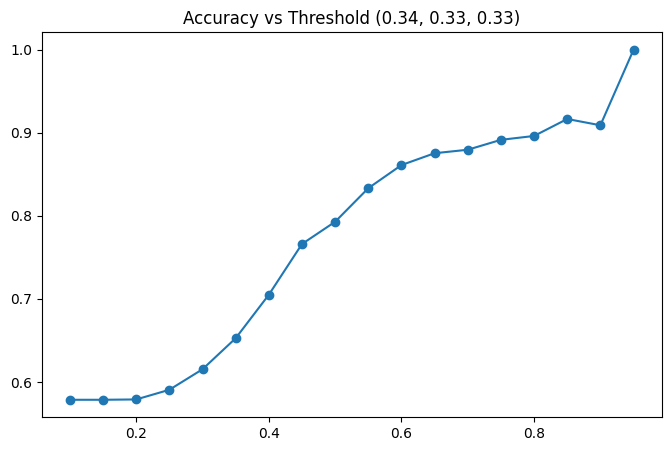

Weights : 0.6,0.3,0.1
              precision    recall  f1-score   support

       Angry       0.58      0.64      0.61       200
     Disgust       0.59      0.61      0.60       200
        Fear       0.40      0.36      0.38       200
       Happy       0.74      0.73      0.73       200
         Sad       0.37      0.30      0.33       200
    Surprise       0.67      0.73      0.70       200
     Neutral       0.52      0.55      0.53       200

    accuracy                           0.56      1400
   macro avg       0.55      0.56      0.55      1400
weighted avg       0.55      0.56      0.55      1400



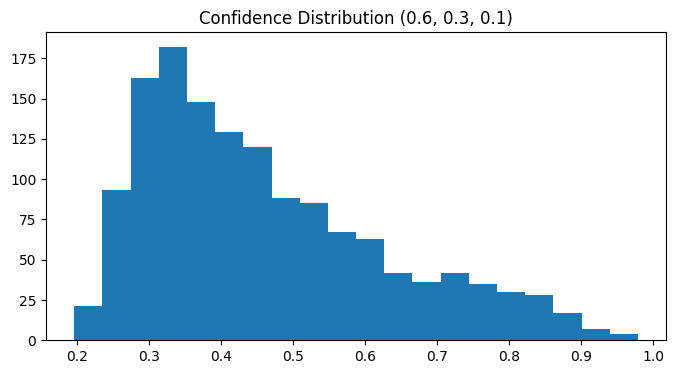

T=0.4 | Accepted=761 | Rejected=639 | Acc=0.7017
T=0.5 | Accepted=473 | Rejected=927 | Acc=0.7865
T=0.6 | Accepted=283 | Rejected=1117 | Acc=0.8693
T=0.7 | Accepted=170 | Rejected=1230 | Acc=0.8824
T=0.8 | Accepted=71 | Rejected=1329 | Acc=0.9155


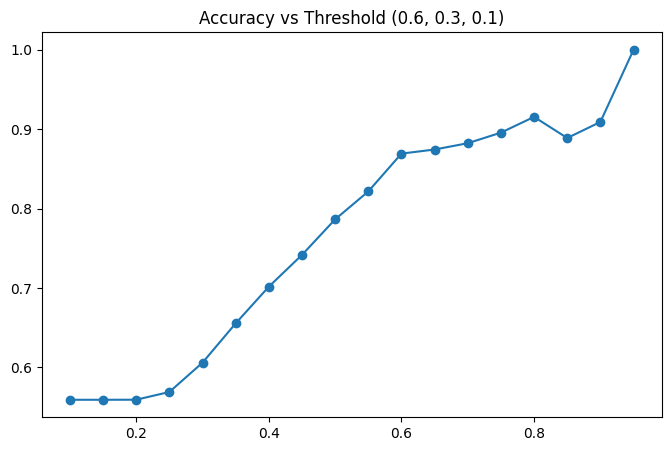

Weights : 0.7,0.2,0.1


In [ ]:
results = []

weight_list = [

    (0.34,0.33,0.33),

    (0.60,0.30,0.10),

    (0.70,0.20,0.10),

    (0.50,0.40,0.10),

    (0.35,0.35,0.30)

]

for h,m,v in weight_list:

    overall,filtered = evaluate_weights(
        h,m,v
    )

    results.append([
        f"{h},{m},{v}",
        overall,
        filtered
    ])

In [ ]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=[
        "Weights",
        "Overall Accuracy",
        "Filtered Accuracy"
    ]
)

results_df

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    results_df["Weights"],
    results_df["Overall Accuracy"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.1,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.ylim(
    min(results_df["Overall Accuracy"])-2,
    max(results_df["Overall Accuracy"])+2
)

plt.title("Overall Accuracy Comparison")

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

bars = plt.bar(
    results_df["Weights"],
    results_df["Filtered Accuracy"]
)

for bar in bars:

    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.title(
    "Filtered Accuracy Comparison"
)

plt.show()

In [ ]:
x = np.arange(len(results_df))

width = 0.35

plt.figure(figsize=(10,5))

plt.bar(
    x-width/2,
    results_df["Overall Accuracy"],
    width,
    label="Overall"
)

plt.bar(
    x+width/2,
    results_df["Filtered Accuracy"],
    width,
    label="Filtered"
)

plt.xticks(
    x,
    results_df["Weights"]
)

plt.legend()

plt.title(
    "Overall vs Filtered Accuracy"
)

plt.show()

In [ ]:
best_overall = results_df.loc[
    results_df["Overall Accuracy"].idxmax()
]

best_filtered = results_df.loc[
    results_df["Filtered Accuracy"].idxmax()
]

print("BEST OVERALL")
print(best_overall)

print()

print("BEST FILTERED")
print(best_filtered)